In [25]:
import asreview
import numpy as np
import pandas as pd
from asreview.models.balancers import Balanced
from asreview.models.classifiers import SVM
from asreview.models.feature_extractors import Tfidf
from asreview.models.queriers import Max

df_res = pd.DataFrame()


def pad_labels(labels, num_priors, num_records):
    return pd.Series(
        labels.tolist() + np.zeros(num_records - len(labels) - num_priors).tolist()
    )


def n_query_extreme(results, n_records):
    if n_records >= 10000:
        if len(results) >= 10000:
            return 10**5
        if len(results) >= 1000:
            return 1000
        elif len(results) >= 100:
            return 25
        else:
            return 1
    else:
        if len(results) >= 1000:
            return 100
        elif len(results) >= 100:
            return 5
        else:
            return 1


def process_study(data, study):
    X = data
    labels = X["label_included"]
    priors = study["prior_inclusions"] + study["prior_exclusions"]

    tfidf_kwargs = {
        "ngram_range": (1, 2),
        "sublinear_tf": True,
        "max_df": 0.95,
        "min_df": 1,
    }

    alc = asreview.ActiveLearningCycle(
        querier=Max(),
        classifier=SVM(C=0.11, loss="squared_hinge"),
        balancer=Balanced(ratio=9.8),
        feature_extractor=Tfidf(**tfidf_kwargs),
        n_query=lambda results: n_query_extreme(results, X.shape[0]),
    )

    # Run simulation
    simulate = asreview.Simulate(X=X, labels=labels, cycles=[alc])
    simulate.label(priors)
    simulate.review()

    df_results = simulate._results.dropna(axis=0, subset="training_set")
    labels_processed = pad_labels(
        df_results["label"].reset_index(drop=True), len(priors), len(X)
    )

    return labels_processed.cumsum()


def run_simulation(
    dataset, studies, output_file):
    results = []
    for study in studies:
        results.append(process_study(dataset, study))

    # Save results
    pd.DataFrame(results).to_csv(output_file, index=False)

In [26]:
dataset = pd.read_excel("./data/masterfile.xlsx", sheet_name="Data")
dataset = dataset[dataset["dup#"] == 1]
dataset["label_included"] = (dataset["Final inclusion\nAny"] >= 1).astype(int)
dataset.reset_index(inplace=True, drop=True)

studies = [
    {"prior_inclusions": [36], "prior_exclusions": [2]},
    {"prior_inclusions": [270], "prior_exclusions": [7234]},
    {"prior_inclusions": [10728], "prior_exclusions": [4350]},
    {"prior_inclusions": [9711], "prior_exclusions": [17]},
    {"prior_inclusions": [4742], "prior_exclusions": [220]},
    
]

run_simulation(dataset, studies, output_file="recalls_u4_improve_combined.csv")
print("SVM simulations complete")

Records labeled       :  53%|█████▎    | 6000/11244 [00:06<00:05, 977.88it/s] 



Loss: 0.067
NDCG: 0.711


Records labeled       :  44%|████▍     | 5000/11244 [00:06<00:07, 822.60it/s] 



Loss: 0.068
NDCG: 0.775


Records labeled       :  53%|█████▎    | 6000/11244 [00:06<00:05, 976.02it/s] 



Loss: 0.074
NDCG: 0.761


Records labeled       :  53%|█████▎    | 6000/11244 [00:06<00:05, 944.38it/s] 



Loss: 0.077
NDCG: 0.703


Records labeled       :  44%|████▍     | 5000/11244 [00:06<00:07, 806.67it/s] 



Loss: 0.072
NDCG: 0.763
SVM simulations complete


In [33]:
recall_files = [
    "recalls_u4_improve_combined.csv",
]
recall_types = [
    "ASR2 TF-IDF + SVM",
]

total_relevant_dict = {"improve": 266}

studies = pd.DataFrame(studies)
recall_dfs = [pd.read_csv(f) for f in recall_files]

In [28]:
# Add metadata to each DataFrame
for i, df in enumerate(recall_dfs):
    df["dataset_name"] = "improve"
    df["Model"] = recall_types[i]
    df["prior_inclusions"] = studies["prior_inclusions"].apply(len)
    df["prior_exclusions"] = studies["prior_exclusions"].apply(len)
    df["simulation_id"] = df.groupby("dataset_name").cumcount() + 1

df_all = pd.concat(recall_dfs, ignore_index=True)
df_all = df_all[df_all["dataset_name"] == "improve"]

df_all_melted = df_all.melt(
    id_vars=[
        "dataset_name",
        "Model",
        "prior_inclusions",
        "prior_exclusions",
        "simulation_id",
    ],
    var_name="step",
    value_name="recall",
).dropna()

df_all_melted["step"] = df_all_melted["step"].astype(int)

df_all_melted["total_relevant"] = df_all_melted["dataset_name"].map(total_relevant_dict)

df_all_melted["relative_recall"] = df_all_melted["recall"] / (
    df_all_melted["total_relevant"] - df_all_melted["prior_inclusions"]
)

# Normalize step values to [0,1]
df_all_melted["relative_step"] = df_all_melted.groupby(["dataset_name", "Model"])[
    "step"
].transform(lambda x: x / x.max())

df_grouped = (
    df_all_melted.groupby(["Model", "relative_step"])["relative_recall"]
    .mean()
    .reset_index()
)

df_grouped["Model"] = pd.Categorical(
    df_grouped["Model"], categories=recall_types, ordered=True
)
df_grouped.sort_values("Model", inplace=True)

In [29]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

# Define zoomed in location + padding
x_min, x_max = 0.0, 0.2
y_min, y_max = 0.8, 1.0
x_padding = 0.05 * (x_max - x_min)
y_padding = 0.05 * (y_max - y_min)

with PdfPages("recall_improve.pdf") as pdf:
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Main plot
    sns.lineplot(
        data=df_grouped,
        x="relative_step",
        y="relative_recall",
        hue="Model",
        ax=axes[0],
        legend=True,
    )

    # Padded rectangle bounds for main plot
    x_start = x_min - x_padding
    y_start = y_min - y_padding
    width = (x_max - x_min) + 2 * x_padding
    height = (y_max - y_min) + 2 * y_padding

    # Draw rectangle on main plot
    rect = patches.Rectangle(
        (x_start, y_start),
        width,
        height,
        linewidth=1,
        edgecolor="black",
        linestyle="--",
        facecolor="none",
        zorder=10,
    )
    axes[0].add_patch(rect)

    axes[0].set_xlabel("Proportion of Documents")
    axes[0].set_ylabel("Mean Recall")
    axes[0].set_title("Full View")

    # Zoomed-in plot
    sns.lineplot(
        data=df_grouped,
        x="relative_step",
        y="relative_recall",
        hue="Model",
        ax=axes[1],
        legend=False,
    )

    axes[1].set_xlim(x_min - x_padding, x_max + x_padding)
    axes[1].set_ylim(y_min - y_padding, y_max + y_padding)
    axes[1].set_xlabel("Proportion of Documents")
    axes[1].set_ylabel("Mean Recall")
    axes[1].set_title("Zoomed View")

    max_relevant = (
        total_relevant_dict["improve"] - 1
    )  # Subtract at least 1 inclusion prior
    total_docs = (
        11242
    )  # subtract at least 1 inclusion and 1 exclusion
    x_perfect = max_relevant / total_docs

    x_vals = np.linspace(0, 1, 10000)
    random_y = x_vals

    perfect_y = np.piecewise(
        x_vals,
        [x_vals <= x_perfect, x_vals > x_perfect],
        [lambda x: x / x_perfect, 1.0],
    )

    for ax in axes:
        ax.plot(
            x_vals, random_y, color="gray", linestyle="--", linewidth=1, label="Random"
        )
        ax.plot(x_vals, perfect_y, color="gray", linewidth=1, label="Perfect")

    handles, labels = axes[0].get_legend_handles_labels()
    axes[0].legend(handles=handles, title="Models + Baselines")

    plt.suptitle("Mean Relative Recall for Improve")
    plt.tight_layout()

    pdf.savefig(fig)
    plt.savefig("02.06.2025 recall_improve.pdf")
    plt.close(fig)

<Axes: xlabel='step', ylabel='recall'>

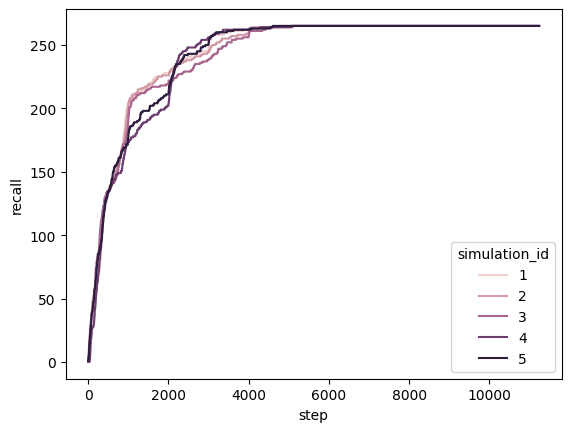

In [30]:
sns.lineplot(
    data=df_all_melted,
    x="step",
    y="recall",
    hue="simulation_id",
    legend=True,
)